In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'date').is_dir() and (p / 'images').is_dir()
)
DATA_DIR = PROJECT_ROOT / 'date'
IMAGES_DIR = PROJECT_ROOT / 'images'
sns.set_theme(style="whitegrid",font_scale = 1.2)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_parquet(DATA_DIR / 'user_behavior_cleaned_dataset.parquet')
df.head()

,user_id,item_id,category_id,behavior_type,timestamp,date
494,114726,2014874,1901483,pv,2017-11-24 16:00:00,2017-11-25
495,108891,4295341,3855599,pv,2017-11-24 16:00:01,2017-11-25
496,127538,1849003,2072473,pv,2017-11-24 16:00:01,2017-11-25
497,104088,4539468,3702593,pv,2017-11-24 16:00:02,2017-11-25
498,111942,1005979,2735466,pv,2017-11-24 16:00:02,2017-11-25


In [3]:
result = df.groupby('date')['user_id'].nunique()
df_result = result.reset_index(name = '每日活跃用户')
print(df_result)
df_result_clean = df_result[(df_result['date'] >= '2017-11-25') & (df_result['date'] <= '2017-12-3')]
df_result_clean

        date  每日活跃用户
0 2017-11-25    7300
1 2017-11-26    7472
2 2017-11-27    7359
3 2017-11-28    7356
4 2017-11-29    7471
5 2017-11-30    7575
6 2017-12-01    7622
7 2017-12-02   10019
8 2017-12-03   10016


,date,每日活跃用户
0,2017-11-25,7300
1,2017-11-26,7472
2,2017-11-27,7359
3,2017-11-28,7356
4,2017-11-29,7471
5,2017-11-30,7575
6,2017-12-01,7622
7,2017-12-02,10019
8,2017-12-03,10016


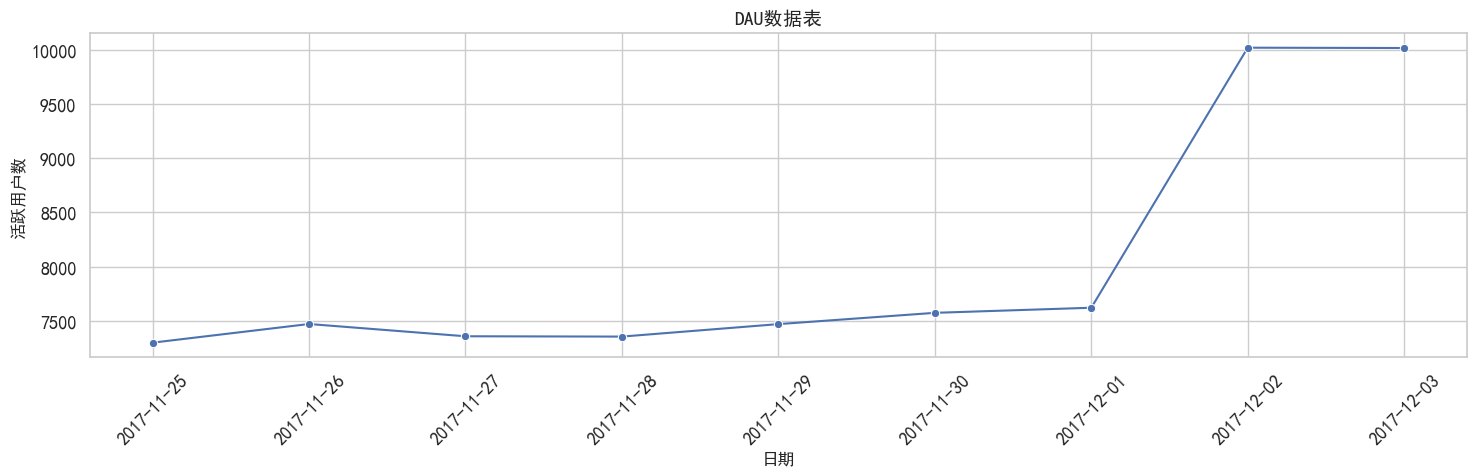

In [4]:
fig,axes = plt.subplots( figsize = (15,5))

sns.lineplot(
    x='date',
    y='每日活跃用户',
    data=df_result_clean,
    marker='o',
    linestyle='-',
    errorbar=None
)
axes.set_title('DAU数据表',fontsize = 14)
axes.set_xlabel('日期',fontsize = 12)
axes.set_ylabel('活跃用户数',fontsize = 12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'DAU regional_monitoring.png',dpi = 300)
plt.show()